In [1]:
import pandas as pd
import numpy as np

In [5]:
pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 8.6 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import re
import nltk

In [7]:
df = pd.read_csv('Reviews.csv.zip')
df = df[['Text', 'Score']]
df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [9]:
from nltk.corpus import stopwords

In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\My
[nltk_data]     Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def clean_text(text):
    # Đảm bảo dữ liệu là dạng chuỗi và chuyển thành chữ thường
    text = str(text).lower()
    # Loại bỏ các thẻ HTML (nếu có)
    text = re.sub(r'<.*?>', '', text)
    # Loại bỏ dấu câu, chữ số, ký tự đặc biệt (chỉ giữ lại chữ cái a-z và khoảng trắng)
    text = re.sub(r'[^a-z\s]', '', text)
    # Loại bỏ các từ dừng (stopwords)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

In [12]:
def convert_score(score):
    if score < 3:       # Điểm 1, 2
        return 0        # 0: Tiêu cực
    elif score == 3:    # Điểm 3
        return 1        # 1: Trung lập
    else:               # Điểm 4, 5
        return 2        # 2: Tích cực

In [13]:
print("Đang xử lý làm sạch văn bản, có thể mất chút thời gian...")
df['Text'] = df['Text'].apply(clean_text)
df['label'] = df['Score'].apply(convert_score)

Đang xử lý làm sạch văn bản, có thể mất chút thời gian...


In [14]:
df.head()

,Text,Score,label
0,bought several vitality canned dog food produc...,5,2
1,product arrived labeled jumbo salted peanutsth...,1,0
2,confection around centuries light pillowy citr...,4,2
3,looking secret ingredient robitussin believe f...,2,0
4,great taffy great price wide assortment yummy ...,5,2


In [15]:
from sklearn.model_selection import train_test_split

# 1. Tách 20% làm tập Test, 80% còn lại làm tập gộp Train_Val
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# 2. Từ 80% tập Train_Val, tách tiếp 20% làm Val và 80% làm Train 
# (Kết quả: Train chiếm 64%, Val chiếm 16% tổng dữ liệu ban đầu)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['label'], random_state=42)

# 3. Tách dữ liệu đầu vào (Text) và nhãn (label) chuyển thành mảng (array) để đưa vào mô hình
X_train = train_df['Text'].values
y_train = train_df['label'].values

X_val = val_df['Text'].values
y_val = val_df['label'].values

X_test = test_df['Text'].values
y_test = test_df['label'].values

# In ra số lượng để kiểm tra
print(f"Số mẫu tập Train (64%): {len(X_train)}")
print(f"Số mẫu tập Validation (16%): {len(X_val)}")
print(f"Số mẫu tập Test (20%): {len(X_test)}")

Số mẫu tập Train (64%): 363810
Số mẫu tập Validation (16%): 90953
Số mẫu tập Test (20%): 113691


In [17]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.8/351.2 MB 6.5 MB/s eta 0:00:54
    --------------------------------------- 7.3/351.2 MB 17.2 MB/s eta 0:00:21
   -- ------------------------------------- 18.9/351.2 MB 28.0 MB/s eta 0:00:12
   --- ------------------------------------ 27.0/351.2 MB 30.4 MB/s eta 0:00:11
   --- ------------------------------------ 34.9/351.2 MB 32.0 MB/s eta 0:00:10
   ---- ----------------------------------- 39.3/351.2 MB 32.5 MB/s eta 0:00:10
   ----- ---------------------------------- 47.7/351.2 MB 31.6 MB/s eta 0:00:10
   ------ --------------------------------- 53.7/351.2 MB 31.4 MB/s eta 0:00:10
   ------ --------------------------------- 59.8/351.2 MB 31.2 MB/s eta 0:00:10
   ------- -------------------------------- 65.8/351.2 MB 30.9 MB/s eta 0:00:10
   -------- ------------------------------- 72.4/351.2 MB 31.


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Thiết lập các siêu tham số (theo đúng báo cáo)
vocab_size = 20000  # Chỉ giữ lại 20.000 từ phổ biến nhất
max_len = 200       # Đưa mọi câu về độ dài cố định là 200 từ

# 1. Khởi tạo Tokenizer và học từ vựng từ tập Train
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 2. Chuyển đổi các câu chữ thành các chuỗi số
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 3. Padding: Đệm hoặc cắt chuỗi để tất cả đều dài đúng 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Kiểm tra kết quả
print(f"Kích thước tập Train sau khi đệm: {X_train_pad.shape}")
print("Ví dụ một câu đã biến thành mảng số:")
print(X_train_pad[0])

Kích thước tập Train sau khi đệm: (363810, 200)
Ví dụ một câu đã biến thành mảng số:
[   7   54 3630  614  111  268   69   51  248  438  223 1164   16    2
  948   46    7   44 1164   88   26 2551  861    6    7    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0   

In [19]:
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# 1. Tính toán trọng số để xử lý mất cân bằng dữ liệu
class_weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Trọng số các lớp (0-Tiêu cực, 1-Trung lập, 2-Tích cực): \n{class_weights_dict}\n")

# 2. Khởi tạo mô hình học sâu Bi-LSTM
embedding_dim = 100 # Kích thước vector biểu diễn từ

model = Sequential([
    # Lớp 1: Lớp Embedding tự học cách hiểu nghĩa của từ
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, trainable=True),
    
    # Lớp 2 & 3: Lớp Bi-LSTM (đọc câu theo cả 2 chiều từ trái sang phải và ngược lại)
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    
    # Lớp 4, 5, 6: Các lớp mạng nơ-ron cơ bản (Dense) xen kẽ Dropout để tránh học vẹt
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    # Lớp Output: Phân loại ra 3 nhóm cảm xúc
    Dense(3, activation='softmax')
])

# 3. In ra cấu trúc tổng quan của mô hình
model.summary()

Trọng số các lớp (0-Tiêu cực, 1-Trung lập, 2-Tích cực): 
{0: np.float64(2.309728782568947), 1: np.float64(4.443752290216197), 2: np.float64(0.42698298687397895)}



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Biên dịch mô hình (Compile)
model.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer=Adam(learning_rate=1e-3), 
    metrics=['accuracy']
)

# 2. Thiết lập cơ chế "Dừng sớm" (Early Stopping)
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 3. Bắt đầu huấn luyện mô hình (Fit)
print("Đang tiến hành huấn luyện. Vui lòng kiên nhẫn...")
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

Đang tiến hành huấn luyện. Vui lòng kiên nhẫn...
Epoch 1/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3710s 1s/step - accuracy: 0.7431 - loss: 0.7363 - val_accuracy: 0.8016 - val_loss: 0.4925
Epoch 2/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3952s 1s/step - accuracy: 0.8090 - loss: 0.5771 - val_accuracy: 0.8130 - val_loss: 0.4817
Epoch 3/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3967s 1s/step - accuracy: 0.8417 - loss: 0.4813 - val_accuracy: 0.8119 - val_loss: 0.4809
Epoch 4/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3949s 1s/step - accuracy: 0.8649 - loss: 0.4018 - val_accuracy: 0.8428 - val_loss: 0.4479
Epoch 5/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3883s 1s/step - accuracy: 0.8853 - loss: 0.3292 - val_accuracy: 0.8423 - val_loss: 0.4341
Epoch 6/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 4051s 1s/step - accuracy: 0.9038 - loss: 0.2707 - val_accuracy: 0.8439 - val_loss: 0.4767
Epoch 7/10
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 3895s 1s/step - accuracy: 0.9163 - loss: 0.2228 - val_accuracy: 0.8484 - val_loss: 0.5026
Epoch 8/10
2843/2843 ━━━━━━

In [21]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


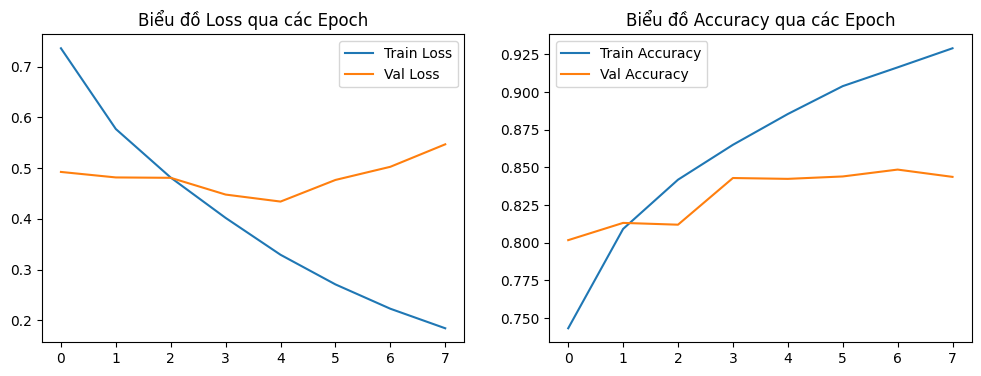

Đang dự đoán trên tập Test. Chờ chút nhé...
3553/3553 ━━━━━━━━━━━━━━━━━━━━ 293s 82ms/step

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
               precision    recall  f1-score   support

 Tiêu cực (0)       0.71      0.77      0.74     16407
Trung lập (1)       0.35      0.67      0.46      8528
 Tích cực (2)       0.97      0.87      0.92     88756

     accuracy                           0.84    113691
    macro avg       0.68      0.77      0.71    113691
 weighted avg       0.88      0.84      0.86    113691



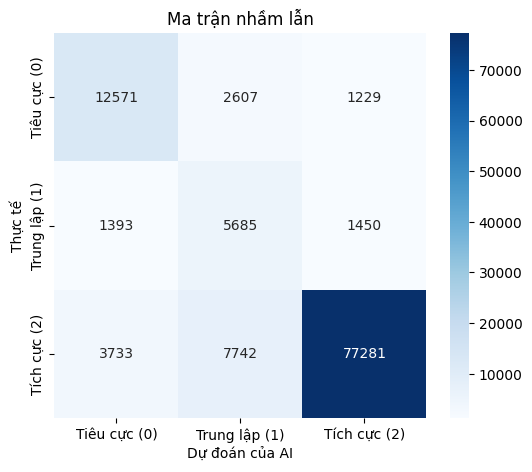

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. VẼ BIỂU ĐỒ QUÁ TRÌNH HỌC (Loss và Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Biểu đồ Loss qua các Epoch')
ax1.legend()

# Biểu đồ Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Biểu đồ Accuracy qua các Epoch')
ax2.legend()
plt.show()

# 2. DỰ ĐOÁN TRÊN TẬP KIỂM THỬ (TEST SET)
print("Đang dự đoán trên tập Test. Chờ chút nhé...")
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. IN BÁO CÁO PHÂN LOẠI (Classification Report)
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
target_names = ['Tiêu cực (0)', 'Trung lập (1)', 'Tích cực (2)']
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# 4. VẼ MA TRẬN NHẦM LẪN (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Dự đoán của AI')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn')
plt.show()

In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Xây dựng hàm dự đoán
def predict_sentiment(sentence, tokenizer, model, max_len=200):
    # 1. Làm sạch câu (sử dụng lại hàm clean_text đã tạo ở bước trước)
    sentence_cleaned = clean_text(sentence)
    
    # 2. Chuyển thành chuỗi số và đệm độ dài
    sequence = tokenizer.texts_to_sequences([sentence_cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post')
    
    # 3. Đưa vào mô hình để dự đoán
    prediction = model.predict(padded)
    label_index = np.argmax(prediction)
    
    # 4. Trả về kết quả
    label_map = {0: 'Tiêu cực (Negative)', 1: 'Trung lập (Neutral)', 2: 'Tích cực (Positive)'}
    return label_map[label_index], prediction

# Thử nghiệm với các câu thực tế (Ghi chú: Dữ liệu học là tiếng Anh nên bạn cần nhập tiếng Anh)
cau_1 = "The food was absolutely wonderful and the service was excellent!"
cau_2 = "The food today is terrible."
cau_3 = "This dish was okay, but not great."

danh_sach_cau = [cau_1, cau_2, cau_3]

for cau in danh_sach_cau:
    label, confidence = predict_sentiment(cau, tokenizer, model)
    print(f"Câu đánh giá: '{cau}'")
    print(f"-> Cảm xúc AI dự đoán: {label}")
    print(f"-> Độ tự tin (Tỉ lệ 3 nhãn): {confidence}")
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Câu đánh giá: 'The food was absolutely wonderful and the service was excellent!'
-> Cảm xúc AI dự đoán: Tích cực (Positive)
-> Độ tự tin (Tỉ lệ 3 nhãn): [[0.00122381 0.00330249 0.9954737 ]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Câu đánh giá: 'The food today is terrible.'
-> Cảm xúc AI dự đoán: Tiêu cực (Negative)
-> Độ tự tin (Tỉ lệ 3 nhãn): [[0.99486476 0.00172497 0.00341022]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Câu đánh giá: 'This dish was okay, but not great.'
-> Cảm xúc AI dự đoán: Trung lập (Neutral)
-> Độ tự tin (Tỉ lệ 3 nhãn): [[0.01270777 0.9524222  0.03487005]]
--------------------------------------------------


In [24]:
import pickle

# 1. Lưu mô hình mạng nơ-ron
model.save('sentiment_bilstm_model.keras')

# 2. Lưu cuốn từ điển Tokenizer
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Đã lưu thành công mô hình và từ điển vào ổ cứng!")

Đã lưu thành công mô hình và từ điển vào ổ cứng!


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import numpy as np

# 1. Nạp lại mô hình và từ điển từ ổ cứng
loaded_model = load_model('sentiment_bilstm_model.keras')
with open('tokenizer.pickle', 'rb') as handle:
    loaded_tokenizer = pickle.load(handle)

# 2. Tạo vòng lặp để nhập tay liên tục
print("=== CHƯƠNG TRÌNH PHÂN TÍCH CẢM XÚC AI ===")
print("Gõ 'thoát' để dừng chương trình.\n")

while True:
    # Lệnh input() cho phép người dùng gõ từ bàn phím
    cau_nhap_tay = input("Nhập câu đánh giá của bạn (tiếng Anh): ")
    
    if cau_nhap_tay.lower() == 'thoát':
        print("Đã thoát chương trình!")
        break
        
    # Tiền xử lý và dự đoán
    sequence = loaded_tokenizer.texts_to_sequences([cau_nhap_tay])
    padded = pad_sequences(sequence, maxlen=200, padding='post')
    prediction = loaded_model.predict(padded, verbose=0) # verbose=0 để ẩn thanh tiến trình cho đỡ rối
    
    label_index = np.argmax(prediction)
    label_map = {0: 'Tiêu cực 😠', 1: 'Trung lập 😐', 2: 'Tích cực 😊'}
    
    print(f"=> Kết quả: {label_map[label_index]}")
    print("-" * 40)

=== CHƯƠNG TRÌNH PHÂN TÍCH CẢM XÚC AI ===
Gõ 'thoát' để dừng chương trình.

=> Kết quả: Tích cực 😊
----------------------------------------
=> Kết quả: Tiêu cực 😠
----------------------------------------
=> Kết quả: Trung lập 😐
----------------------------------------
=> Kết quả: Tiêu cực 😠
----------------------------------------
=> Kết quả: Tiêu cực 😠
----------------------------------------
=> Kết quả: Tiêu cực 😠
----------------------------------------
=> Kết quả: Tiêu cực 😠
----------------------------------------
